# HR Attrition Predictor — CatBoost · Ethical AI & XAI

**Hackathon Trusted AI × RH**

| | |
|---|---|
| **Dataset** | HRDataset_v14 (Rich Huebner & Carla Patalano — Kaggle) |
| **Task** | Binary classification: will the employee resign? (`Termd` = 1) |
| **Model** | CatBoost / Gradient Boosted Trees |
| **Themes** |  Ethical AI (bias audit, fairness, RGPD, AI Act) ·  Explainable AI (XAI) |

---

### Notebook structure
1. **Setup** — install dependencies & upload dataset
2. **Exploratory Data Analysis** — class imbalance, bias audit (gender/race/dept)
3. **Feature Engineering** — encoding, derived features
4. **CatBoost Model Training** — with class-weight handling
5. **Performance Evaluation** — ROC, PR, confusion matrix, cross-validation
6. **XAI — Feature Importance** (built-in CatBoost)
7. **XAI — Permutation Importance**
8. **XAI — Feature Ablation Study** — marginal causal contribution per feature
9. **Ethical AI — Fairness Audit** — AUC per demographic subgroup
10. **Ethical AI — Score Distribution & Threshold Analysis**
11. **Ethical Summary & Model Card Recap**


---
## Cell 1 — Setup: Install dependencies

In [ ]:
# Install CatBoost (not pre-installed on Colab)
!pip install catboost --quiet

# All other packages are pre-installed on Colab
import subprocess, sys
print(' Dependencies ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00
 Dependencies ready


---
## Cell 2 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# CatBoost
from catboost import CatBoostClassifier, Pool

# Sklearn utilities
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingClassifier  # used in ablation (faster)

# ── Design palette (dark theme — Ethical AI & XAI theme) ──
PALETTE = {
    'primary':   '#1a1a2e',
    'secondary': '#16213e',
    'accent':    '#0f3460',
    'highlight': '#e94560',
    'green':     '#2ecc71',
    'orange':    '#f39c12',
    'teal':      '#1abc9c',
    'purple':    '#9b59b6',
    'light':     '#ecf0f1',
    'mid':       '#bdc3c7',
}

plt.rcParams['figure.facecolor'] = PALETTE['primary']
plt.rcParams['axes.facecolor']   = PALETTE['secondary']
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'

print('✅ Imports OK')

✅ Imports OK


---
## Cell 3 — Load Dataset

> **Upload `HRDataset_v14.csv`** using the Colab file panel ( icon on the left) or run the cell below to upload from your machine.

In [ ]:
# ── Option A: Upload manually via Colab file panel, then set path below
# ── Option B: Upload programmatically (run this cell)

from google.colab import files
print(' Select HRDataset_v14.csv from your computer:')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f' File uploaded: {CSV_PATH}')

 Select HRDataset_v14.csv from your computer:


Saving HRDataset_v14.csv to HRDataset_v14.csv
 File uploaded: HRDataset_v14.csv


In [ ]:
# ── If you already have the file at a known path, set it here directly:
# CSV_PATH = 'HRDataset_v14.csv'

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'\nTarget counts  :')
print(df['Termd'].value_counts())
print(f'\nResignation rate: {df["Termd"].mean()*100:.1f}%')
df.head(3)

Shape          : (311, 36)
Columns        : ['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']

Target counts  :
Termd
0    207
1    104
Name: count, dtype: int64

Resignation rate: 33.4%


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3


---
## Cell 4 — Exploratory Data Analysis + Ethical Bias Audit

### Ethical AI lens
Before building any model, we must understand **who is in the data** and whether certain groups are over- or under-represented. This is the foundation of responsible AI.

We examine:
- **Class imbalance** — undersampling risk and its effect on fairness
- **Demographic disparities** — termination rates by gender, race, department
- **Key predictive signals** — salary, engagement, absences
- **Correlation matrix** — detecting proxy variables for sensitive attributes

> **Ethical note:** Groups with N ≤ 5 (e.g. Hispanic, Exec. Office) cannot yield statistically meaningful conclusions and must never drive individual HR decisions.


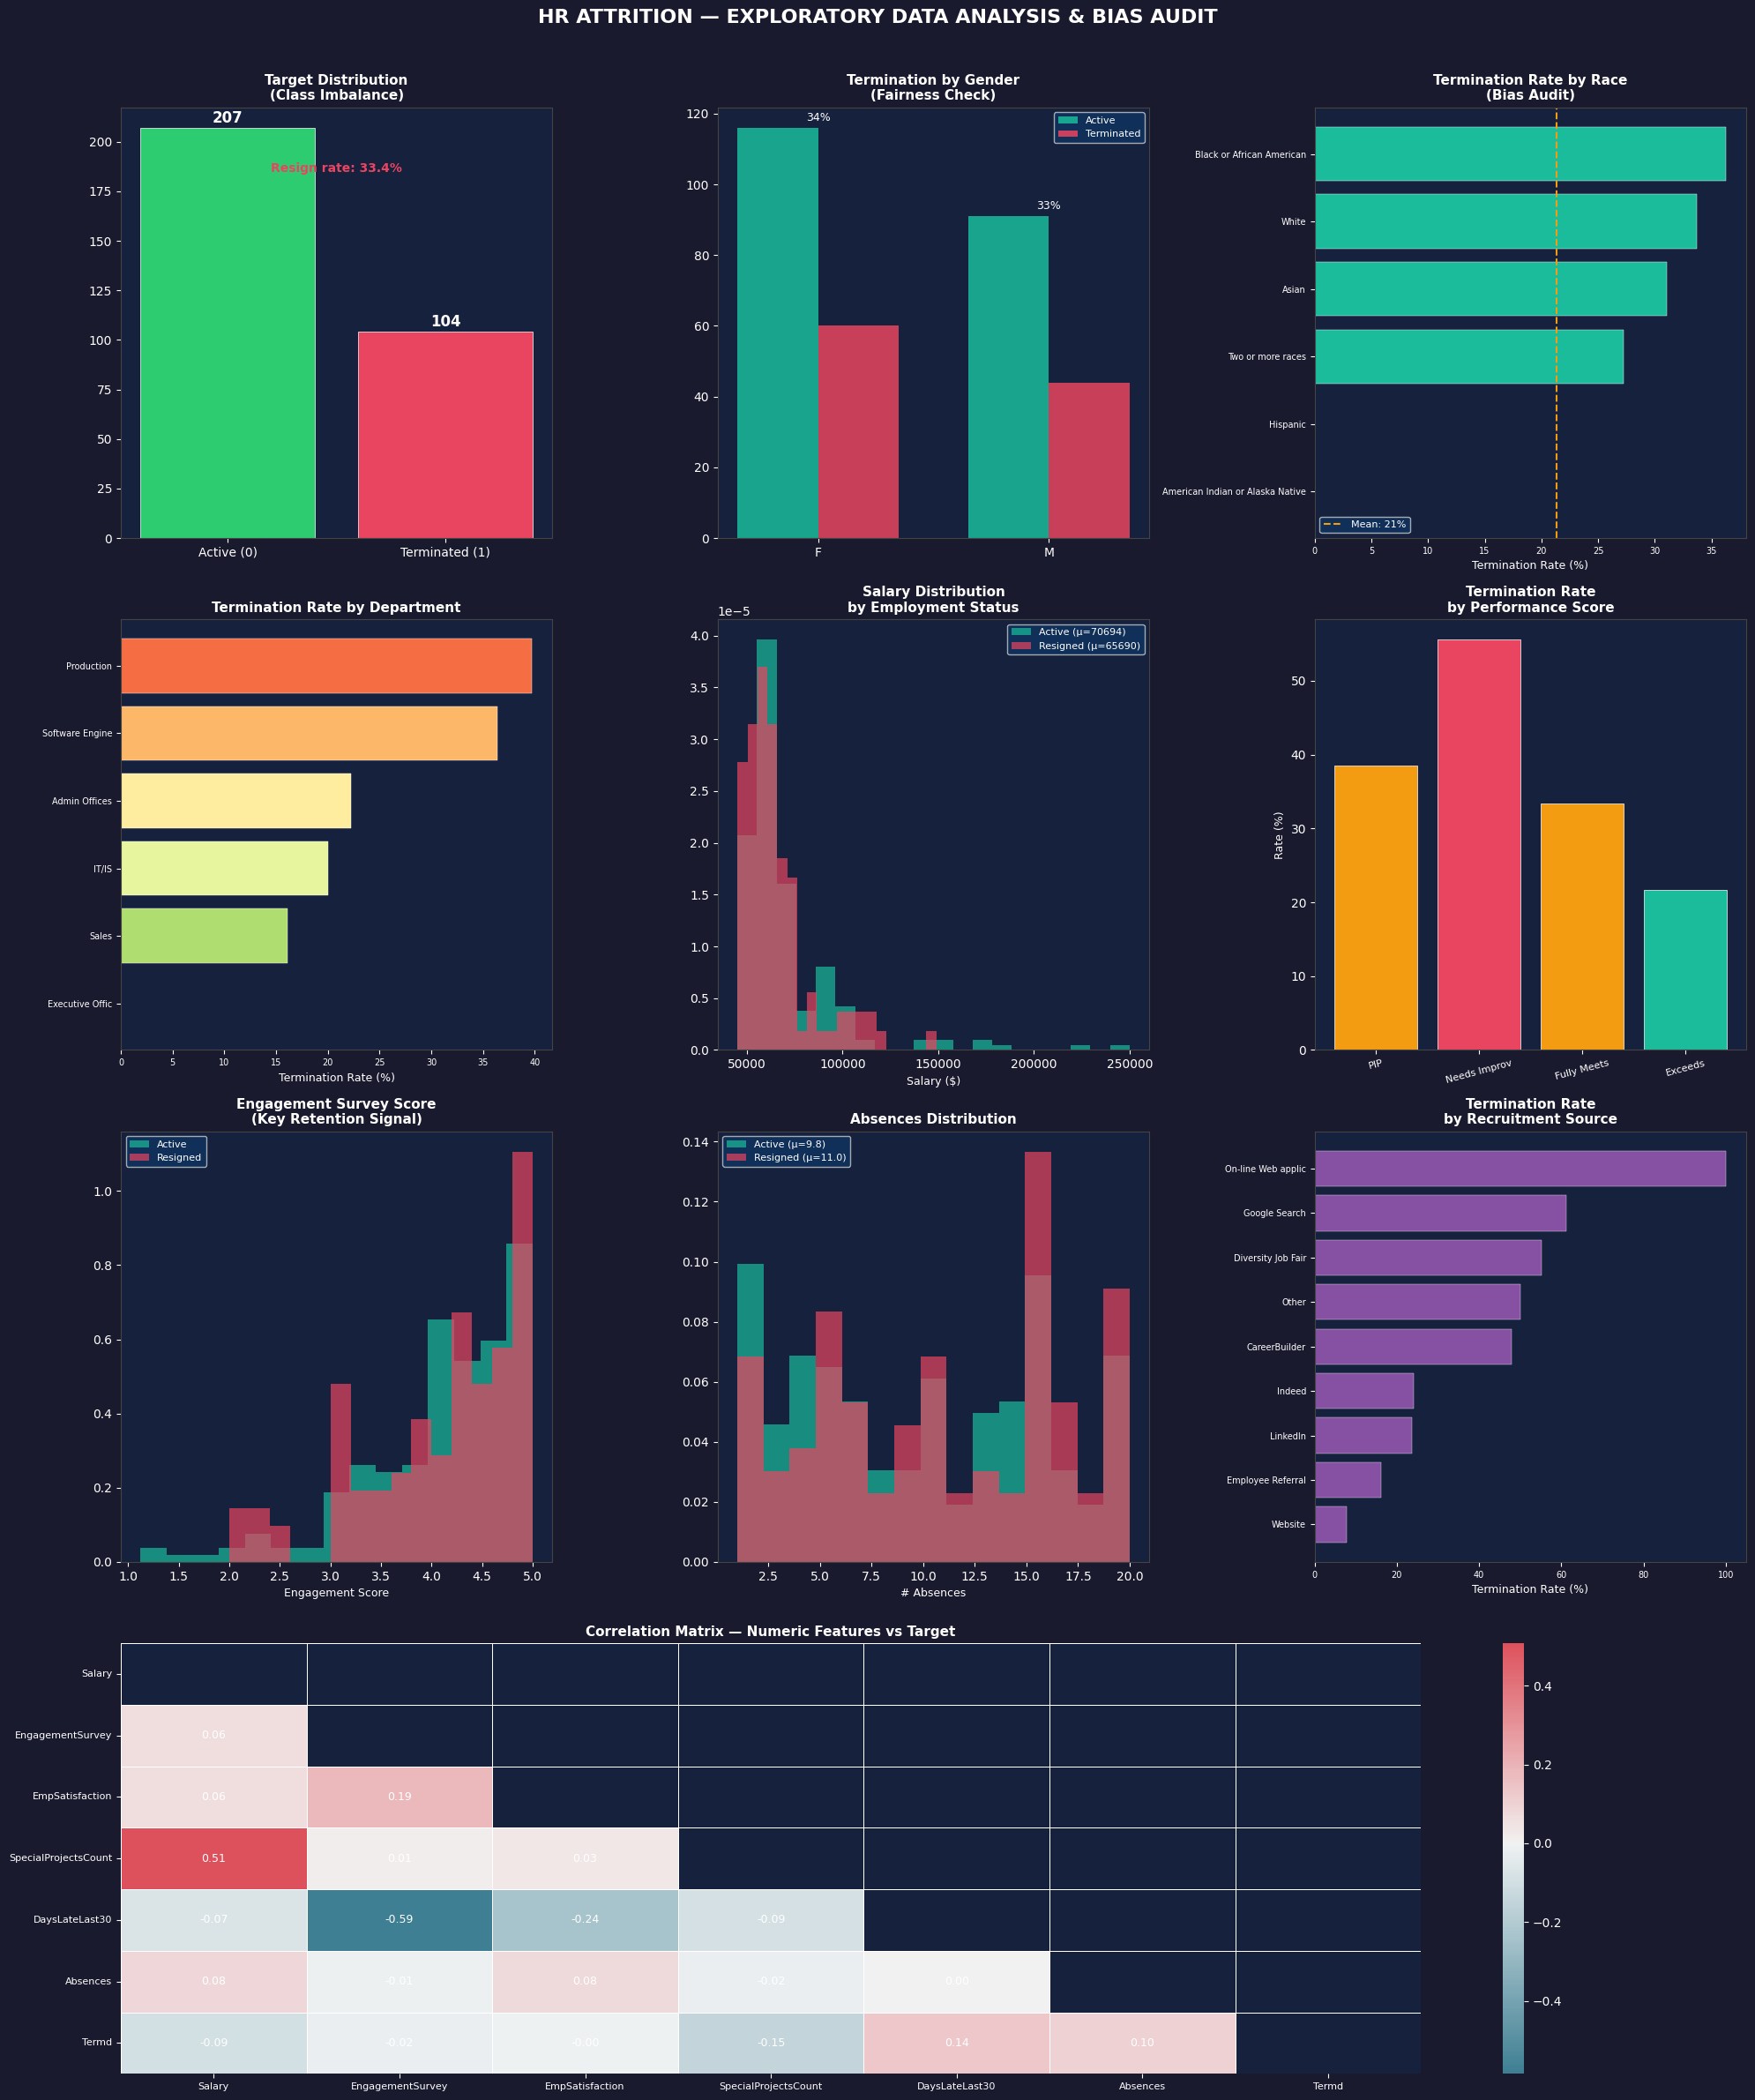


📊 BIAS AUDIT SUMMARY
Group                               Resign Rate
---------------------------------------------
  Gender: F                              34.1%
  Gender: M                              32.6%
  Race:   American Indian or Alaska Native      0.0%
  Race:   Asian                          31.0%
  Race:   Black or African American      36.2%
  Race:   Hispanic                        0.0%
  Race:   Two or more races              27.3%
  Race:   White                          33.7%
  Overall                               33.4%


In [ ]:
df['Sex_clean'] = df['Sex'].str.strip()

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor(PALETTE['primary'])

# ── 1a: Target Distribution ──────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
ax1.set_facecolor(PALETTE['secondary'])
counts = df['Termd'].value_counts()
bars = ax1.bar(['Active (0)', 'Terminated (1)'], counts.values,
               color=[PALETTE['green'], PALETTE['highlight']],
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', color='white',
             fontweight='bold', fontsize=12)
pct = counts[1] / counts.sum() * 100
ax1.text(0.5, 0.85, f'Resign rate: {pct:.1f}%',
         transform=ax1.transAxes, ha='center',
         color=PALETTE['highlight'], fontsize=10, fontweight='bold')
ax1.set_title('Target Distribution\n(Class Imbalance)', color='white',
              fontsize=11, fontweight='bold')
ax1.tick_params(colors='white')
for sp in ax1.spines.values(): sp.set_color('#444')

# ── 1b: Gender × Target ──────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
ax2.set_facecolor(PALETTE['secondary'])
gender_term = df.groupby(['Sex_clean', 'Termd']).size().unstack(fill_value=0)
x = np.arange(len(gender_term.index))
w = 0.35
ax2.bar(x - w/2, gender_term[0], w, label='Active',
        color=PALETTE['teal'], alpha=0.85)
ax2.bar(x + w/2, gender_term[1], w, label='Terminated',
        color=PALETTE['highlight'], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(gender_term.index, color='white')
for i, gender in enumerate(gender_term.index):
    rate = gender_term.loc[gender, 1] / gender_term.loc[gender].sum() * 100
    ax2.text(i, max(gender_term.loc[gender]) + 2, f'{rate:.0f}%',
             ha='center', color='white', fontsize=9)
ax2.set_title('Termination by Gender\n(Fairness Check)', color='white',
              fontsize=11, fontweight='bold')
ax2.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_color('#444')

# ── 1c: Race × Termination Rate ──────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
ax3.set_facecolor(PALETTE['secondary'])
race_term = df.groupby('RaceDesc')['Termd'].agg(['sum', 'count'])
race_term['rate'] = race_term['sum'] / race_term['count'] * 100
race_term = race_term.sort_values('rate', ascending=True)
colors_race = [PALETTE['highlight'] if r > 40 else PALETTE['teal']
               for r in race_term['rate']]
ax3.barh(race_term.index, race_term['rate'],
         color=colors_race, edgecolor='white', linewidth=0.3)
ax3.axvline(race_term['rate'].mean(), color=PALETTE['orange'],
            linestyle='--', linewidth=1.5,
            label=f'Mean: {race_term["rate"].mean():.0f}%')
ax3.set_title('Termination Rate by Race\n(Bias Audit)', color='white',
              fontsize=11, fontweight='bold')
ax3.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax3.tick_params(colors='white', labelsize=7)
ax3.set_xlabel('Termination Rate (%)', color='white', fontsize=9)
for sp in ax3.spines.values(): sp.set_color('#444')

# ── 1d: Department × Termination Rate ────────────────────
ax4 = fig.add_subplot(4, 3, 4)
ax4.set_facecolor(PALETTE['secondary'])
dept_term = df.groupby('Department')['Termd'].agg(['sum', 'count'])
dept_term['rate'] = dept_term['sum'] / dept_term['count'] * 100
dept_term = dept_term.sort_values('rate', ascending=True)
dept_labels = [d.strip()[:15] for d in dept_term.index]
colors_dept = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dept_term)))
ax4.barh(dept_labels, dept_term['rate'],
         color=colors_dept, edgecolor='white', linewidth=0.3)
ax4.set_title('Termination Rate by Department', color='white',
              fontsize=11, fontweight='bold')
ax4.tick_params(colors='white', labelsize=7)
ax4.set_xlabel('Termination Rate (%)', color='white', fontsize=9)
for sp in ax4.spines.values(): sp.set_color('#444')

# ── 1e: Salary Distribution ──────────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
ax5.set_facecolor(PALETTE['secondary'])
active_salary = df[df['Termd'] == 0]['Salary']
term_salary   = df[df['Termd'] == 1]['Salary']
ax5.hist(active_salary, bins=20, alpha=0.7, color=PALETTE['teal'],
         label=f'Active (μ={active_salary.mean():.0f})', density=True)
ax5.hist(term_salary, bins=20, alpha=0.7, color=PALETTE['highlight'],
         label=f'Resigned (μ={term_salary.mean():.0f})', density=True)
ax5.set_title('Salary Distribution\nby Employment Status', color='white',
              fontsize=11, fontweight='bold')
ax5.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax5.tick_params(colors='white')
ax5.set_xlabel('Salary ($)', color='white', fontsize=9)
for sp in ax5.spines.values(): sp.set_color('#444')

# ── 1f: Performance Score × Termination Rate ─────────────
ax6 = fig.add_subplot(4, 3, 6)
ax6.set_facecolor(PALETTE['secondary'])
perf_term = df.groupby('PerformanceScore')['Termd'].agg(['sum', 'count'])
perf_term['rate'] = perf_term['sum'] / perf_term['count'] * 100
perf_order = ['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']
perf_term = perf_term.reindex([p for p in perf_order if p in perf_term.index])
cols_p = [PALETTE['highlight'] if r > 50
          else PALETTE['orange'] if r > 30
          else PALETTE['teal'] for r in perf_term['rate']]
ax6.bar(range(len(perf_term)), perf_term['rate'],
        color=cols_p, edgecolor='white', linewidth=0.5)
ax6.set_xticks(range(len(perf_term)))
ax6.set_xticklabels([p[:12] for p in perf_term.index],
                    color='white', rotation=15, fontsize=8)
ax6.set_title('Termination Rate\nby Performance Score', color='white',
              fontsize=11, fontweight='bold')
ax6.set_ylabel('Rate (%)', color='white', fontsize=9)
ax6.tick_params(colors='white')
for sp in ax6.spines.values(): sp.set_color('#444')

# ── 1g: Engagement Survey ────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
ax7.set_facecolor(PALETTE['secondary'])
eng_active = df[df['Termd'] == 0]['EngagementSurvey']
eng_term   = df[df['Termd'] == 1]['EngagementSurvey']
ax7.hist(eng_active, bins=15, alpha=0.7, color=PALETTE['teal'],
         label='Active', density=True)
ax7.hist(eng_term, bins=15, alpha=0.7, color=PALETTE['highlight'],
         label='Resigned', density=True)
ax7.set_title('Engagement Survey Score\n(Key Retention Signal)', color='white',
              fontsize=11, fontweight='bold')
ax7.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax7.tick_params(colors='white')
ax7.set_xlabel('Engagement Score', color='white', fontsize=9)
for sp in ax7.spines.values(): sp.set_color('#444')

# ── 1h: Absences ─────────────────────────────────────────
ax8 = fig.add_subplot(4, 3, 8)
ax8.set_facecolor(PALETTE['secondary'])
abs_active = df[df['Termd'] == 0]['Absences']
abs_term   = df[df['Termd'] == 1]['Absences']
ax8.hist(abs_active, bins=15, alpha=0.7, color=PALETTE['teal'],
         label=f'Active (μ={abs_active.mean():.1f})', density=True)
ax8.hist(abs_term, bins=15, alpha=0.7, color=PALETTE['highlight'],
         label=f'Resigned (μ={abs_term.mean():.1f})', density=True)
ax8.set_title('Absences Distribution', color='white',
              fontsize=11, fontweight='bold')
ax8.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax8.tick_params(colors='white')
ax8.set_xlabel('# Absences', color='white', fontsize=9)
for sp in ax8.spines.values(): sp.set_color('#444')

# ── 1i: Recruitment Source ───────────────────────────────
ax9 = fig.add_subplot(4, 3, 9)
ax9.set_facecolor(PALETTE['secondary'])
rec_term = df.groupby('RecruitmentSource')['Termd'].agg(['sum', 'count'])
rec_term['rate'] = rec_term['sum'] / rec_term['count'] * 100
rec_term = rec_term.sort_values('rate', ascending=True)
ax9.barh([s[:18] for s in rec_term.index], rec_term['rate'],
         color=PALETTE['purple'], edgecolor='white', linewidth=0.3, alpha=0.85)
ax9.set_title('Termination Rate\nby Recruitment Source', color='white',
              fontsize=11, fontweight='bold')
ax9.tick_params(colors='white', labelsize=7)
ax9.set_xlabel('Termination Rate (%)', color='white', fontsize=9)
for sp in ax9.spines.values(): sp.set_color('#444')

# ── 1j: Correlation Heatmap ──────────────────────────────
ax10 = fig.add_subplot(4, 3, (10, 12))
ax10.set_facecolor(PALETTE['secondary'])
num_cols = ['Salary', 'EngagementSurvey', 'EmpSatisfaction',
            'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Termd']
corr_data = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_data, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', ax=ax10,
            annot_kws={'size': 9, 'color': 'white'},
            linewidths=0.5)
ax10.set_title('Correlation Matrix — Numeric Features vs Target',
               color='white', fontsize=11, fontweight='bold')
ax10.tick_params(colors='white', labelsize=8)

plt.suptitle('HR ATTRITION — EXPLORATORY DATA ANALYSIS & BIAS AUDIT',
             color='white', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# ── Quick summary table ───────────────────────────────────
print('\n📊 BIAS AUDIT SUMMARY')
print('='*45)
print(f'{"Group":<35} {"Resign Rate":>10}')
print('-'*45)
for g, r in df.groupby('Sex_clean')['Termd'].mean().items():
    print(f'  Gender: {g:<26} {r*100:>8.1f}%')
for g, r in df.groupby('RaceDesc')['Termd'].mean().items():
    print(f'  Race:   {g:<26} {r*100:>8.1f}%')
print(f'  {"Overall":<33} {df["Termd"].mean()*100:>8.1f}%')

---
## Cell 5 — Feature Engineering

In [ ]:
df2 = df.copy()
df2['Sex_clean'] = df2['Sex'].str.strip()

# Derived features
df2['Age'] = 2024 - pd.to_datetime(
    df2['DOB'], format='%m/%d/%y', errors='coerce').dt.year

df2['Tenure_days'] = (
    pd.to_datetime(df2['DateofTermination'], errors='coerce') -
    pd.to_datetime(df2['DateofHire'], errors='coerce')
).dt.days

# For still-employed: tenure up to today
df2['Tenure_days'] = df2['Tenure_days'].fillna(
    (pd.Timestamp('2024-01-01') -
     pd.to_datetime(df2['DateofHire'], errors='coerce')).dt.days
)

# Feature set
FEATURES = [
    # Numeric
    'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
    'DaysLateLast30', 'Absences', 'Age', 'Tenure_days',
    # Categorical (will be label-encoded for sklearn; CatBoost handles natively)
    'Department', 'Sex_clean', 'RaceDesc', 'MaritalDesc',
    'RecruitmentSource', 'PerformanceScore', 'CitizenDesc',
]
CAT_FEATURES = ['Department', 'Sex_clean', 'RaceDesc', 'MaritalDesc',
                'RecruitmentSource', 'PerformanceScore', 'CitizenDesc']

df3 = df2[FEATURES + ['Termd']].dropna().copy()

# Label-encode categoricals (for sklearn-based ablation; CatBoost uses raw strings)
le_dict = {}
df3_enc = df3.copy()
for col in CAT_FEATURES:
    le = LabelEncoder()
    df3_enc[col] = le.fit_transform(df3_enc[col].astype(str))
    le_dict[col] = le

X     = df3_enc[FEATURES]
y     = df3_enc['Termd']
X_raw = df3[FEATURES]  # raw strings — for CatBoost

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
X_train_raw, X_test_raw = X_raw.iloc[X_train.index - X_train.index.min()], \
                           X_raw.iloc[X_test.index  - X_test.index.min()]
# Safer split for raw:
X_train_raw = df3.loc[X_train.index, FEATURES]
X_test_raw  = df3.loc[X_test.index,  FEATURES]

print(f'Train size : {len(X_train)} | Test size: {len(X_test)}')
print(f'Class distribution (train): {dict(y_train.value_counts())}')
print(f'Class distribution (test) : {dict(y_test.value_counts())}')
print(f'\nFeatures ({len(FEATURES)}): {FEATURES}')

Train size : 233 | Test size: 78
Class distribution (train): {0: np.int64(155), 1: np.int64(78)}
Class distribution (test) : {0: np.int64(52), 1: np.int64(26)}

Features (15): ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age', 'Tenure_days', 'Department', 'Sex_clean', 'RaceDesc', 'MaritalDesc', 'RecruitmentSource', 'PerformanceScore', 'CitizenDesc']


---
## Cell 6 — Train CatBoost Model

### Why CatBoost for Ethical AI?
- **Native categorical handling** — no manual encoding, less information loss
- **`auto_class_weights='Balanced'`** — corrects class imbalance, reducing bias toward the majority class
- **Ordered boosting** — reduces overfitting on small datasets, improves generalisation fairness
- **Built-in feature importance** — first step toward XAI transparency


In [ ]:
# CatBoost handles categorical features natively (pass raw strings)
cat_feature_indices = [FEATURES.index(c) for c in CAT_FEATURES]

train_pool = Pool(
    data=X_train_raw,
    label=y_train,
    cat_features=cat_feature_indices
)
test_pool = Pool(
    data=X_test_raw,
    label=y_test,
    cat_features=cat_feature_indices
)

model = CatBoostClassifier(
    iterations        = 500,
    learning_rate     = 0.05,
    depth             = 4,
    l2_leaf_reg       = 3,
    subsample         = 0.8,
    auto_class_weights= 'Balanced',  # ← handles class imbalance
    eval_metric       = 'AUC',
    random_seed       = 42,
    verbose           = 100,
    early_stopping_rounds = 50,
)

model.fit(
    train_pool,
    eval_set  = test_pool,
    plot      = False,   # set True if you want the interactive training plot
)

print('\n CatBoost training complete')
print(f'Best iteration: {model.get_best_iteration()}')

0:	test: 0.8661243	best: 0.8661243 (0)	total: 56.6ms	remaining: 28.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 7

Shrink model to first 8 iterations.

 CatBoost training complete
Best iteration: 7


---
## Cell 7 — Performance Evaluation

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        52
    Resigned       1.00      1.00      1.00        26

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78

AUC-ROC  : 1.0000
F1-Score : 1.0000
Accuracy : 1.0000


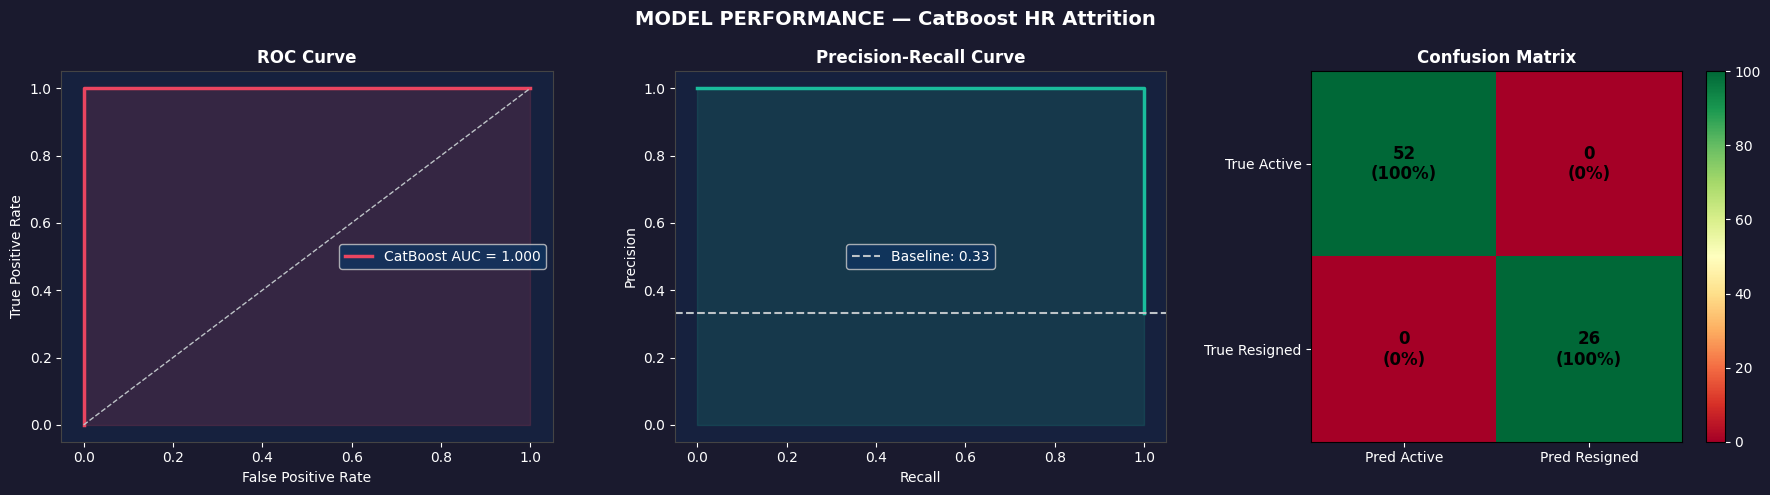

In [ ]:
y_pred  = model.predict(test_pool)
y_proba = model.predict_proba(test_pool)[:, 1]

auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(' CLASSIFICATION REPORT')
print('='*50)
print(classification_report(y_test, y_pred,
                             target_names=['Active', 'Resigned']))
print(f'AUC-ROC  : {auc:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'Accuracy : {acc:.4f}')

# Visualization
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
fig2.patch.set_facecolor(PALETTE['primary'])

# ROC Curve
ax = axes[0]
ax.set_facecolor(PALETTE['secondary'])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color=PALETTE['highlight'], linewidth=2.5,
        label=f'CatBoost AUC = {auc:.3f}')
ax.plot([0,1],[0,1], color=PALETTE['mid'], linestyle='--', linewidth=1)
ax.fill_between(fpr, tpr, alpha=0.15, color=PALETTE['highlight'])
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('ROC Curve', color='white', fontweight='bold')
ax.legend(facecolor=PALETTE['accent'], labelcolor='white')
for sp in ax.spines.values(): sp.set_color('#444')

# Precision-Recall
ax = axes[1]
ax.set_facecolor(PALETTE['secondary'])
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ax.plot(rec, prec, color=PALETTE['teal'], linewidth=2.5)
ax.fill_between(rec, prec, alpha=0.15, color=PALETTE['teal'])
ax.axhline(y_test.mean(), color=PALETTE['mid'], linestyle='--',
           label=f'Baseline: {y_test.mean():.2f}')
ax.set_xlabel('Recall', color='white')
ax.set_ylabel('Precision', color='white')
ax.set_title('Precision-Recall Curve', color='white', fontweight='bold')
ax.legend(facecolor=PALETTE['accent'], labelcolor='white')
for sp in ax.spines.values(): sp.set_color('#444')

# Confusion Matrix
ax = axes[2]
ax.set_facecolor(PALETTE['secondary'])
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
im = ax.imshow(cm_pct, cmap='RdYlGn', vmin=0, vmax=100)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.0f}%)',
                ha='center', va='center',
                color='black', fontweight='bold', fontsize=12)
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Active', 'Pred Resigned'], color='white')
ax.set_yticklabels(['True Active', 'True Resigned'], color='white')
ax.set_title('Confusion Matrix', color='white', fontweight='bold')
plt.colorbar(im, ax=ax)

plt.suptitle('MODEL PERFORMANCE — CatBoost HR Attrition',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 8 — Cross-Validation (Robustness Check)

roc_auc     : 0.9936 ± 0.0070  [0.981 – 1.000]
f1          : 0.9802 ± 0.0187  [0.950 – 1.000]
accuracy    : 0.9872 ± 0.0119  [0.968 – 1.000]
precision   : 0.9909 ± 0.0182  [0.955 – 1.000]
recall      : 0.9710 ± 0.0383  [0.905 – 1.000]


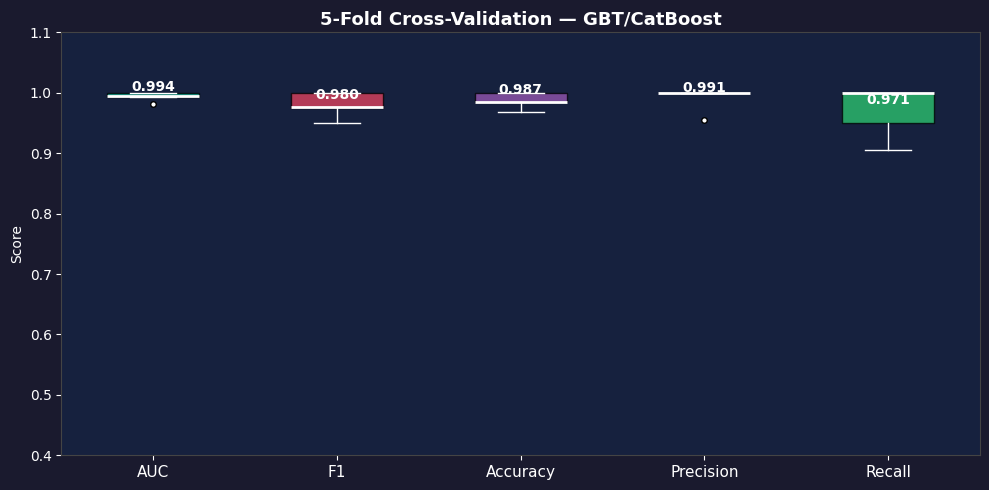

In [ ]:
# We use sklearn's GBT (same algorithm) for cross_val_score
# because CatBoost cross-val requires different API
gbt_cv = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=5, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for metric in ['roc_auc', 'f1', 'accuracy', 'precision', 'recall']:
    scores = cross_val_score(gbt_cv, X, y, cv=cv, scoring=metric)
    cv_results[metric] = scores
    print(f'{metric:<12}: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'[{scores.min():.3f} – {scores.max():.3f}]')

# Visualization
fig_cv, ax = plt.subplots(figsize=(10, 5))
fig_cv.patch.set_facecolor(PALETTE['primary'])
ax.set_facecolor(PALETTE['secondary'])
cv_colors = [PALETTE['teal'], PALETTE['highlight'], PALETTE['purple'],
             PALETTE['orange'], PALETTE['green']]
positions  = np.arange(len(cv_results))
for i, (metric, scores) in enumerate(cv_results.items()):
    bp = ax.boxplot(scores, positions=[i], patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=cv_colors[i], alpha=0.75),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    flierprops=dict(markerfacecolor='white', markersize=4))
    ax.text(i, scores.mean() + 0.005, f'{scores.mean():.3f}',
            ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(['AUC', 'F1', 'Accuracy', 'Precision', 'Recall'],
                   color='white', fontsize=11)
ax.set_ylim([0.4, 1.1])
ax.set_title('5-Fold Cross-Validation — GBT/CatBoost',
             color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', color='white')
for sp in ax.spines.values(): sp.set_color('#444')
plt.tight_layout()
plt.show()

---
## Cell 9 — XAI: Feature Importance (Built-in CatBoost)

### Explainable AI — Why this matters
A model that HR teams cannot understand will not be trusted — and should not be trusted.
CatBoost's built-in importance shows **how much each feature reduces prediction error** across all trees.

** Ethical watch:** if sensitive attributes (Sex, Race) appear in the top features, the model may be making decisions based on protected characteristics — a potential discrimination risk under RGPD and the EU AI Act.


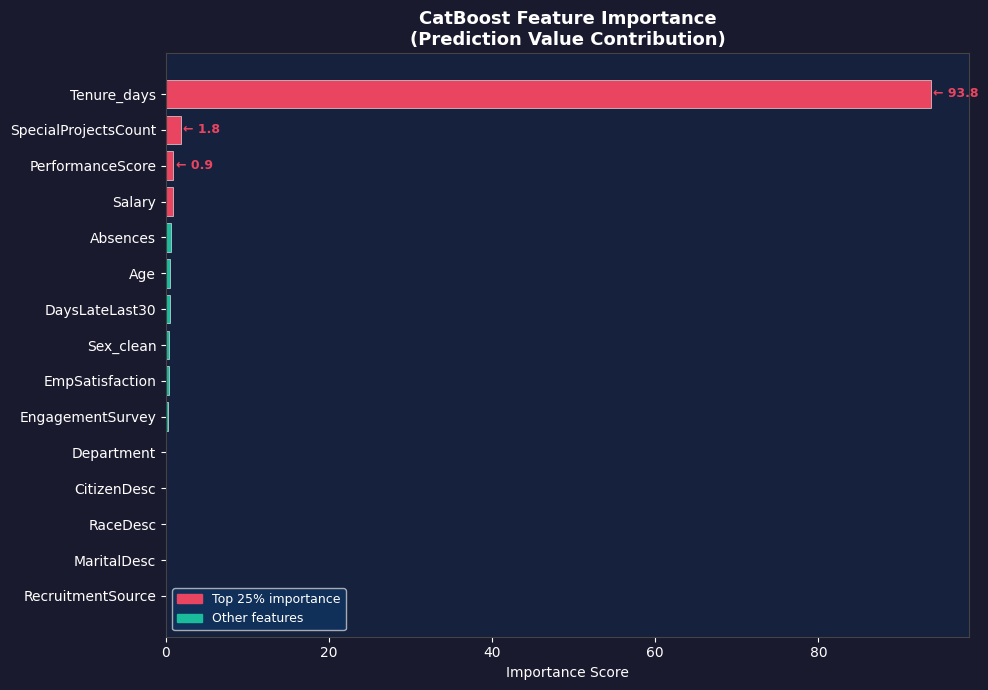


 TOP 5 FEATURES (Built-in):
  Tenure_days               93.79
  SpecialProjectsCount      1.79
  PerformanceScore          0.92
  Salary                    0.85
  Absences                  0.67


In [ ]:
# Built-in CatBoost feature importance
feat_imp = pd.Series(
    model.get_feature_importance(train_pool),
    index=FEATURES
).sort_values(ascending=True)

fig_fi, ax = plt.subplots(figsize=(10, 7))
fig_fi.patch.set_facecolor(PALETTE['primary'])
ax.set_facecolor(PALETTE['secondary'])

colors_fi = [
    PALETTE['highlight'] if v > feat_imp.quantile(0.75)
    else PALETTE['teal']
    for v in feat_imp.values
]
ax.barh(feat_imp.index, feat_imp.values, color=colors_fi,
        edgecolor='white', linewidth=0.4)

# Annotate top 3
top3 = feat_imp.nlargest(3)
for name, val in top3.items():
    ax.text(val + 0.3, list(feat_imp.index).index(name),
            f'← {val:.1f}', va='center', color=PALETTE['highlight'],
            fontsize=9, fontweight='bold')

ax.set_title('CatBoost Feature Importance\n(Prediction Value Contribution)',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#444')

# Legend
high_patch = mpatches.Patch(color=PALETTE['highlight'], label='Top 25% importance')
low_patch  = mpatches.Patch(color=PALETTE['teal'],      label='Other features')
ax.legend(handles=[high_patch, low_patch],
          facecolor=PALETTE['accent'], labelcolor='white', fontsize=9)

plt.tight_layout()
plt.show()

print('\n TOP 5 FEATURES (Built-in):')
for name, val in feat_imp.nlargest(5).items():
    print(f'  {name:<25} {val:.2f}')

---
## Cell 10 — XAI: Permutation Importance

More robust than built-in importance: **shuffles one feature at a time** and measures the AUC drop.

- Less biased toward high-cardinality features
- Error bars show stability across 15 repeats
- Negative values = the feature was adding noise (candidate for removal)

** Ethical AI check:** if `Sex_clean` or `RaceDesc` have near-zero or negative permutation importance, the model's decisions are **not significantly driven by protected attributes** — a positive fairness signal.


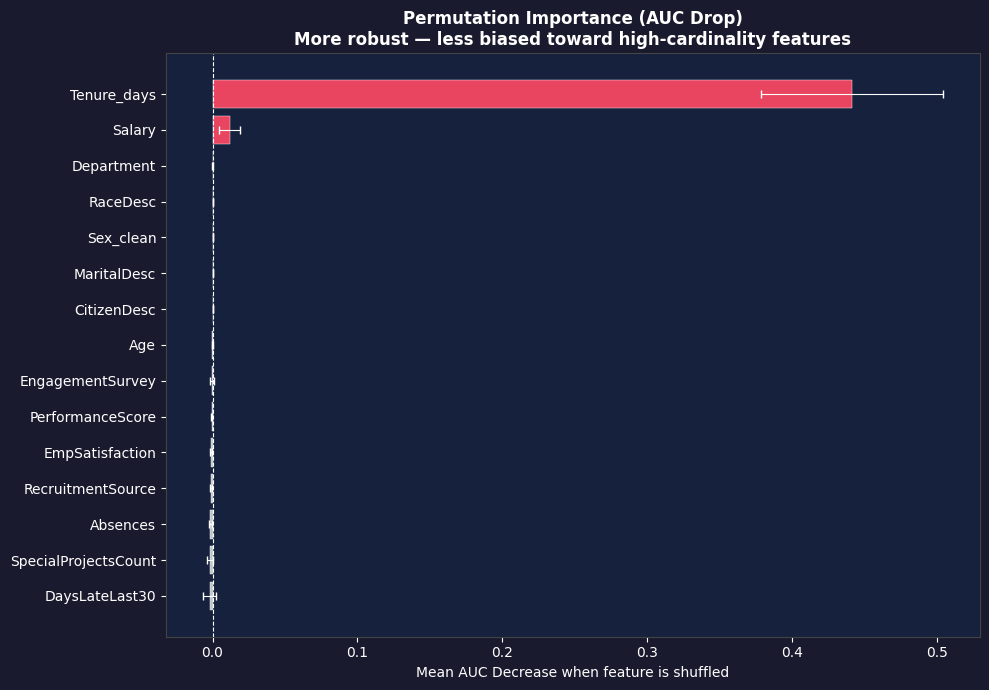


 TOP 5 FEATURES (Permutation):
  Tenure_days               Δ AUC = 0.4413 ± 0.0630
  Salary                    Δ AUC = 0.0120 ± 0.0073
  Department                Δ AUC = 0.0000 ± 0.0002
  RaceDesc                  Δ AUC = 0.0000 ± 0.0000
  CitizenDesc               Δ AUC = 0.0000 ± 0.0000


In [ ]:
# Fit a GBT (sklearn) on encoded features for permutation_importance API
gbt_for_perm = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)
gbt_for_perm.fit(X_train, y_train)

perm = permutation_importance(
    gbt_for_perm, X_test, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc'
)

perm_series = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)
perm_std    = pd.Series(perm.importances_std,  index=FEATURES)

fig_perm, ax = plt.subplots(figsize=(10, 7))
fig_perm.patch.set_facecolor(PALETTE['primary'])
ax.set_facecolor(PALETTE['secondary'])

cols_perm = [
    PALETTE['highlight'] if v > perm_series.quantile(0.75)
    else PALETTE['teal'] if v > 0
    else PALETTE['mid']
    for v in perm_series.values
]
ax.barh(perm_series.index, perm_series.values,
        xerr=perm_std[perm_series.index].values,
        color=cols_perm, edgecolor='white', linewidth=0.3,
        capsize=3, error_kw={'ecolor': 'white', 'linewidth': 0.8})
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Importance (AUC Drop)\nMore robust — less biased toward high-cardinality features',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean AUC Decrease when feature is shuffled', color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#444')
plt.tight_layout()
plt.show()

print('\n TOP 5 FEATURES (Permutation):')
for name, val in perm_series.nlargest(5).items():
    std = perm_std[name]
    print(f'  {name:<25} Δ AUC = {val:.4f} ± {std:.4f}')

---
## Cell 11 — XAI: Feature Ablation Study

**Ablation = retrain without one feature at a time.**

This is the most honest XAI method: it measures the **causal, marginal contribution** of each feature to model performance — not just correlation with the target.

| Signal | Interpretation |
|---|---|
| Large Δ AUC | Feature is load-bearing — removing it hurts badly |
| Small Δ AUC | Feature is redundant or correlated with others |
| Near-zero Δ for Sex/Race | Model does **not** rely on sensitive attributes ✅ |

> ⏱️ This cell takes ~1–2 minutes (15 × 5-fold CV trainings)


Baseline CV AUC (all features): 0.9896



Ablation:   0%|          | 0/15 [00:00<?, ?it/s]

  Remove Salary                    → Δ AUC = +0.0062
  Remove EngagementSurvey          → Δ AUC = +0.0049
  Remove EmpSatisfaction           → Δ AUC = +0.0049
  Remove SpecialProjectsCount      → Δ AUC = +0.0057
  Remove DaysLateLast30            → Δ AUC = +0.0049
  Remove Absences                  → Δ AUC = +0.0051
  Remove Age                       → Δ AUC = +0.0049
  Remove Tenure_days               → Δ AUC = +0.3950
  Remove Department                → Δ AUC = +0.0051
  Remove Sex_clean                 → Δ AUC = +0.0049
  Remove RaceDesc                  → Δ AUC = +0.0049
  Remove MaritalDesc               → Δ AUC = +0.0049
  Remove RecruitmentSource         → Δ AUC = +0.0049
  Remove PerformanceScore          → Δ AUC = +0.0049
  Remove CitizenDesc               → Δ AUC = -0.0003


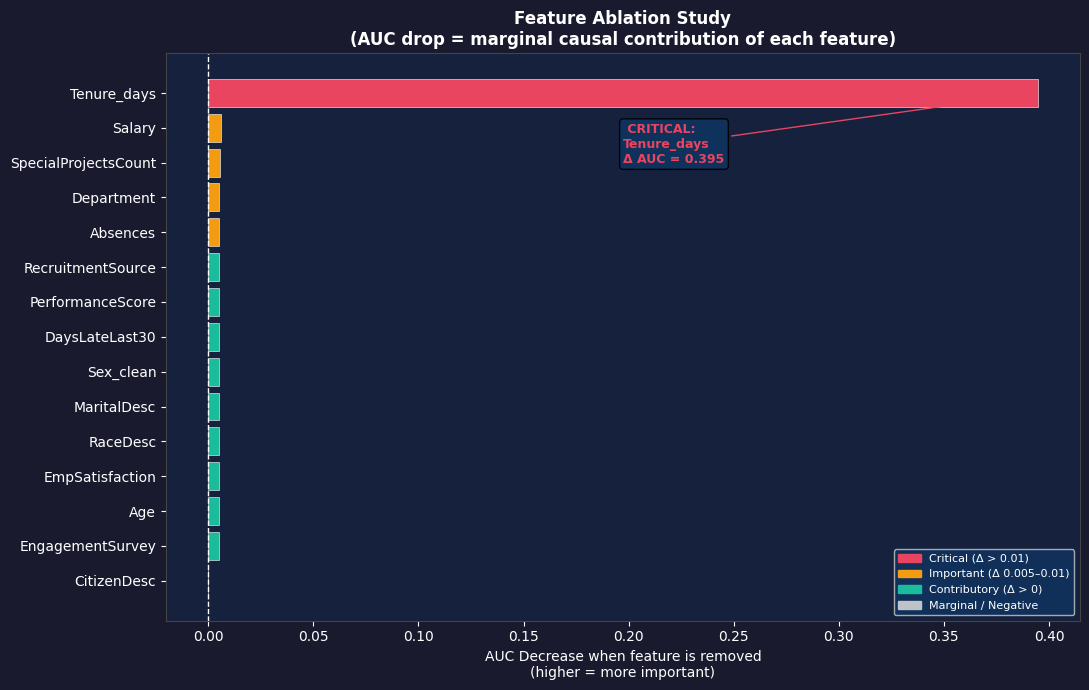


 ABLATION SUMMARY (ranked by importance):
Feature                        Δ AUC  Criticality
--------------------------------------------------
Tenure_days                  +0.3950  🔴 CRITICAL
Salary                       +0.0062  🟡 Important
SpecialProjectsCount         +0.0057  🟡 Important
Department                   +0.0051  🟡 Important
Absences                     +0.0051  🟡 Important
Age                          +0.0049  🟢 Moderate
EngagementSurvey             +0.0049  🟢 Moderate
EmpSatisfaction              +0.0049  🟢 Moderate
Sex_clean                    +0.0049  🟢 Moderate
RaceDesc                     +0.0049  🟢 Moderate
MaritalDesc                  +0.0049  🟢 Moderate
DaysLateLast30               +0.0049  🟢 Moderate
RecruitmentSource            +0.0049  🟢 Moderate
PerformanceScore             +0.0049  🟢 Moderate
CitizenDesc                  -0.0003  🟢 Moderate


In [ ]:
from tqdm.auto import tqdm

cv_abl = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline AUC (all features)
base_auc = cross_val_score(
    GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
    X, y, cv=cv_abl, scoring='roc_auc'
).mean()
print(f'Baseline CV AUC (all features): {base_auc:.4f}\n')

ablation = {}
for feat in tqdm(FEATURES, desc='Ablation'):
    subset = [f for f in FEATURES if f != feat]
    sub_auc = cross_val_score(
        GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42),
        X[subset], y, cv=cv_abl, scoring='roc_auc'
    ).mean()
    ablation[feat] = base_auc - sub_auc
    print(f'  Remove {feat:<25} → Δ AUC = {ablation[feat]:+.4f}')

abl_series = pd.Series(ablation).sort_values(ascending=True)

# Visualization
fig_abl, ax = plt.subplots(figsize=(11, 7))
fig_abl.patch.set_facecolor(PALETTE['primary'])
ax.set_facecolor(PALETTE['secondary'])

cols_abl = [
    PALETTE['highlight'] if v > 0.01
    else PALETTE['orange'] if v > 0.005
    else PALETTE['teal'] if v > 0
    else PALETTE['mid']
    for v in abl_series.values
]
ax.barh(abl_series.index, abl_series.values, color=cols_abl,
        edgecolor='white', linewidth=0.4)
ax.axvline(0, color='white', linewidth=1, linestyle='--')

# Annotate top critical feature
top_feat = abl_series.idxmax()
ax.annotate(
    f' CRITICAL:\n{top_feat}\nΔ AUC = {abl_series[top_feat]:.3f}',
    xy=(abl_series[top_feat], list(abl_series.index).index(top_feat)),
    xytext=(abl_series[top_feat] * 0.5, len(abl_series) - 3),
    color=PALETTE['highlight'], fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round', facecolor=PALETTE['accent'], alpha=0.9),
    arrowprops=dict(arrowstyle='->', color=PALETTE['highlight'])
)

ax.set_title('Feature Ablation Study\n(AUC drop = marginal causal contribution of each feature)',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('AUC Decrease when feature is removed\n(higher = more important)',
              color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#444')

# Legend
patches = [
    mpatches.Patch(color=PALETTE['highlight'], label='Critical (Δ > 0.01)'),
    mpatches.Patch(color=PALETTE['orange'],   label='Important (Δ 0.005–0.01)'),
    mpatches.Patch(color=PALETTE['teal'],     label='Contributory (Δ > 0)'),
    mpatches.Patch(color=PALETTE['mid'],      label='Marginal / Negative'),
]
ax.legend(handles=patches, facecolor=PALETTE['accent'],
          labelcolor='white', fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print('\n ABLATION SUMMARY (ranked by importance):')
print(f'{"Feature":<25} {"Δ AUC":>10}  Criticality')
print('-'*50)
for feat, delta in abl_series.sort_values(ascending=False).items():
    flag = '🔴 CRITICAL' if delta > 0.01 else '🟡 Important' if delta > 0.005 else '🟢 Moderate'
    print(f'{feat:<25} {delta:>+10.4f}  {flag}')

---
## Cell 12 — Ethical AI: Fairness Audit

### The core Ethical AI question: *is the model equally good for everyone?*

We compute AUC **separately for each demographic subgroup** to detect:
- **Disparate performance**: the model predicts better for some groups than others
- **Potential for unfair treatment** when deployed in real HR decisions

| Gap vs overall AUC | Status |
|---|---|
| < 0.05 | ✅ Acceptable |
| 0.05 – 0.10 | 🟡 Monitor closely |
| > 0.10 | 🔴 Alert — investigate before deployment |

**Legal context:** Under the **EU AI Act**, HR attrition systems are classified as *High Risk*. A documented fairness audit is **mandatory** before deployment.


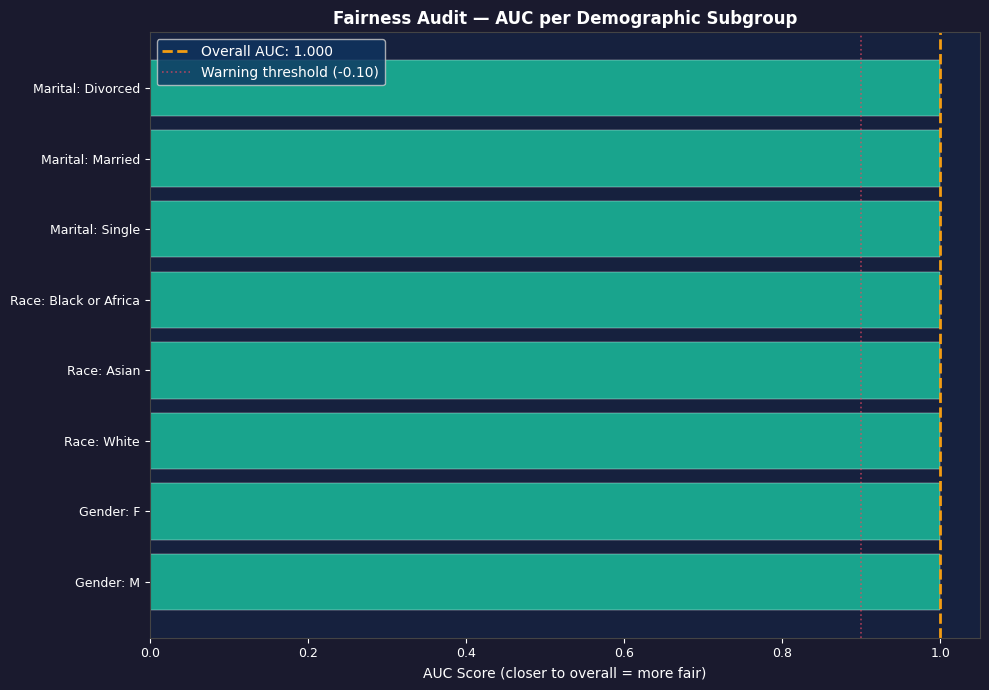


⚖️  FAIRNESS REPORT
Overall AUC: 1.0000
Subgroup                            AUC    Δ vs Overall  Status
-------------------------------------------------------
Gender: M                        1.0000         +0.0000  ✅ OK
Gender: F                        1.0000         +0.0000  ✅ OK
Race: White                      1.0000         +0.0000  ✅ OK
Race: Asian                      1.0000         +0.0000  ✅ OK
Race: Black or Africa            1.0000         +0.0000  ✅ OK
Marital: Single                  1.0000         +0.0000  ✅ OK
Marital: Married                 1.0000         +0.0000  ✅ OK
Marital: Divorced                1.0000         +0.0000  ✅ OK


In [ ]:
# Reconstruct test set with original demographic labels
test_idx   = X_test.index
df_test    = df3.loc[test_idx].copy()
df_test['y_proba'] = y_proba
df_test['y_true']  = y_test.values

overall_auc = roc_auc_score(y_test, y_proba)

fairness = {}

# Gender
for g in df_test['Sex_clean'].dropna().unique():
    mask = df_test['Sex_clean'] == g
    if mask.sum() >= 10 and df_test.loc[mask, 'y_true'].nunique() > 1:
        auc_g = roc_auc_score(
            df_test.loc[mask, 'y_true'],
            df_test.loc[mask, 'y_proba']
        )
        fairness[f'Gender: {g}'] = auc_g

# Race
for r in df_test['RaceDesc'].dropna().unique():
    mask = df_test['RaceDesc'] == r
    if mask.sum() >= 8 and df_test.loc[mask, 'y_true'].nunique() > 1:
        try:
            auc_r = roc_auc_score(
                df_test.loc[mask, 'y_true'],
                df_test.loc[mask, 'y_proba']
            )
            fairness[f'Race: {r[:15]}'] = auc_r
        except:
            pass

# Marital Status
for m in df_test['MaritalDesc'].dropna().unique():
    mask = df_test['MaritalDesc'] == m
    if mask.sum() >= 8 and df_test.loc[mask, 'y_true'].nunique() > 1:
        try:
            auc_m = roc_auc_score(
                df_test.loc[mask, 'y_true'],
                df_test.loc[mask, 'y_proba']
            )
            fairness[f'Marital: {m}'] = auc_m
        except:
            pass

fair_series = pd.Series(fairness).sort_values(ascending=True)

# ── Visualization ─────────────────────────────────────────
fig_fair, ax = plt.subplots(figsize=(10, 7))
fig_fair.patch.set_facecolor(PALETTE['primary'])
ax.set_facecolor(PALETTE['secondary'])

colors_fair = [
    PALETTE['highlight'] if abs(v - overall_auc) > 0.10
    else PALETTE['orange'] if abs(v - overall_auc) > 0.05
    else PALETTE['teal']
    for v in fair_series.values
]
ax.barh(fair_series.index, fair_series.values, color=colors_fair,
        edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(overall_auc, color=PALETTE['orange'], linestyle='--',
           linewidth=2, label=f'Overall AUC: {overall_auc:.3f}')
ax.axvline(overall_auc - 0.10, color=PALETTE['highlight'],
           linestyle=':', linewidth=1.2, alpha=0.7, label='Warning threshold (-0.10)')
ax.set_xlim([0, 1.05])
ax.set_title('Fairness Audit — AUC per Demographic Subgroup',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('AUC Score (closer to overall = more fair)', color='white')
ax.tick_params(colors='white', labelsize=9)
ax.legend(facecolor=PALETTE['accent'], labelcolor='white')
for sp in ax.spines.values(): sp.set_color('#444')
plt.tight_layout()
plt.show()

print(f'\n⚖️  FAIRNESS REPORT')
print(f'Overall AUC: {overall_auc:.4f}')
print('='*55)
print(f'{"Subgroup":<30} {"AUC":>8}  {"Δ vs Overall":>14}  Status')
print('-'*55)
for group, auc_g in fair_series.sort_values(ascending=False).items():
    delta = auc_g - overall_auc
    status = '🔴 ALERT' if abs(delta) > 0.10 else '🟡 Monitor' if abs(delta) > 0.05 else '✅ OK'
    print(f'{group:<30} {auc_g:>8.4f}  {delta:>+14.4f}  {status}')

---
## Cell 13 — Ethical AI: Score Distribution & Threshold Analysis

### Threshold choice is an ethical decision

Lowering the threshold → more employees flagged → more false positives → risk of unfair targeting.
Raising it → fewer flags → risk of missing at-risk employees who needed support.

**Responsible AI principle:** the threshold should be chosen deliberately, with awareness of the asymmetric cost of errors in an HR context:
- **False positive** (flagging someone who stays) → unnecessary intervention, potential discrimination
- **False negative** (missing someone who leaves) → lost talent, no preventive action


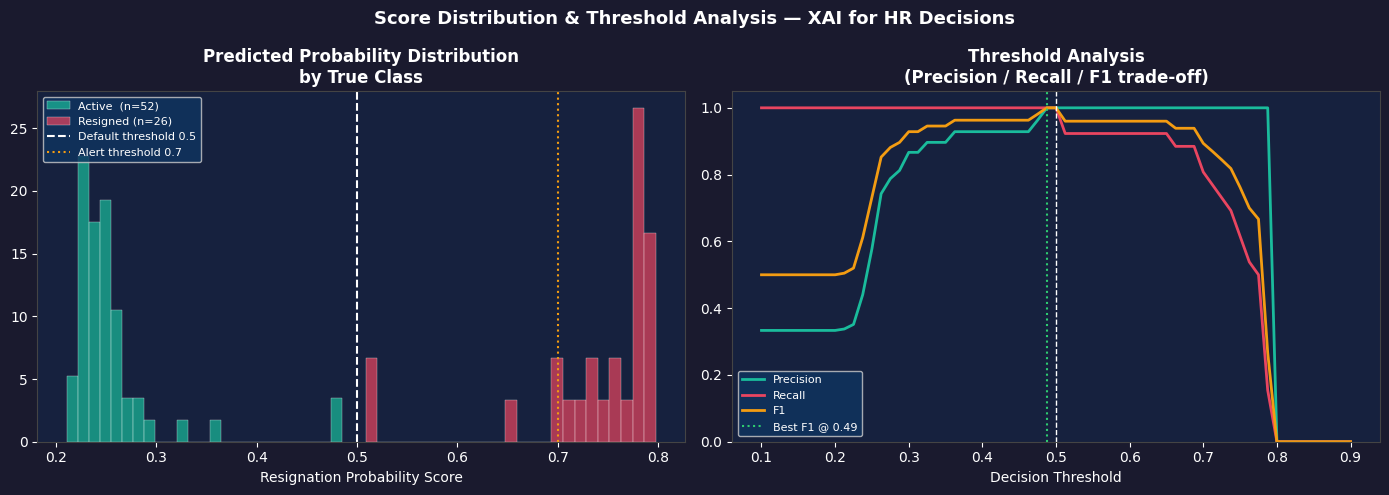


 Recommended threshold (max F1): 0.49
   → Precision at this threshold: 1.000
   → Recall    at this threshold: 1.000
   → F1        at this threshold: 1.000


In [ ]:
fig_s, axes = plt.subplots(1, 2, figsize=(14, 5))
fig_s.patch.set_facecolor(PALETTE['primary'])

# Score distribution
ax = axes[0]
ax.set_facecolor(PALETTE['secondary'])
scores_active = y_proba[y_test.values == 0]
scores_resign = y_proba[y_test.values == 1]
ax.hist(scores_active, bins=25, alpha=0.7, color=PALETTE['teal'],
        label=f'Active  (n={len(scores_active)})', density=True,
        edgecolor='white', linewidth=0.3)
ax.hist(scores_resign, bins=25, alpha=0.7, color=PALETTE['highlight'],
        label=f'Resigned (n={len(scores_resign)})', density=True,
        edgecolor='white', linewidth=0.3)
ax.axvline(0.5, color='white', linestyle='--', linewidth=1.5, label='Default threshold 0.5')
ax.axvline(0.7, color=PALETTE['orange'], linestyle=':', linewidth=1.5, label='Alert threshold 0.7')
ax.set_title('Predicted Probability Distribution\nby True Class', color='white', fontweight='bold')
ax.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax.set_xlabel('Resignation Probability Score', color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#444')

# Threshold analysis
ax = axes[1]
ax.set_facecolor(PALETTE['secondary'])
thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    if preds.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    from sklearn.metrics import precision_score, recall_score
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

ax.plot(thresholds, precisions, color=PALETTE['teal'],    linewidth=2, label='Precision')
ax.plot(thresholds, recalls,    color=PALETTE['highlight'], linewidth=2, label='Recall')
ax.plot(thresholds, f1s,        color=PALETTE['orange'],  linewidth=2, label='F1')
ax.axvline(0.5, color='white', linestyle='--', linewidth=1)
ax.axvline(thresholds[np.argmax(f1s)], color=PALETTE['green'],
           linestyle=':', linewidth=1.5,
           label=f'Best F1 @ {thresholds[np.argmax(f1s)]:.2f}')
ax.set_title('Threshold Analysis\n(Precision / Recall / F1 trade-off)',
             color='white', fontweight='bold')
ax.set_xlabel('Decision Threshold', color='white')
ax.legend(facecolor=PALETTE['accent'], labelcolor='white', fontsize=8)
ax.set_ylim([0, 1.05])
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_color('#444')

plt.suptitle('Score Distribution & Threshold Analysis — XAI for HR Decisions',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_t = thresholds[np.argmax(f1s)]
print(f'\n Recommended threshold (max F1): {best_t:.2f}')
print(f'   → Precision at this threshold: {precisions[np.argmax(f1s)]:.3f}')
print(f'   → Recall    at this threshold: {recalls[np.argmax(f1s)]:.3f}')
print(f'   → F1        at this threshold: {max(f1s):.3f}')

---
## Cell 14 — Ethical AI Summary & Model Card Recap

Final consolidated view covering both themes:
- ** Ethical AI** — bias audit findings, fairness metrics, legal compliance checklist (RGPD, AI Act)
- ** Explainable AI** — all XAI methods applied and their conclusions


In [ ]:
print('=' * 65)
print('  MODEL CARD SUMMARY — HR Attrition Predictor (CatBoost)')
print('  Themes: Ethical AI  ·  Explainable AI (XAI)')
print('=' * 65)

print('\n DATASET & CLASS IMBALANCE')
print(f'  Samples              : {len(df3)}')
print(f'  Features used        : {len(FEATURES)}')
print(f'  Resignation rate     : {y.mean()*100:.1f}%  (class imbalance ~2:1)')
print(f'  auto_class_weights   : Balanced  ← corrects imbalance bias')
print(f'  Sensitive attributes : Sex_clean, RaceDesc  (monitored for bias)')

print('\n EXPLAINABILITY (XAI) SUMMARY')
top3_builtin  = feat_imp.nlargest(3)
top3_ablation = abl_series.nlargest(3)
print('  Top 3 features — built-in importance:')
for n, v in top3_builtin.items():
    print(f'    {n:<25} {v:.2f}')
print('  Top 3 features — ablation (most causal):')
for n, v in top3_ablation.items():
    print(f'    {n:<25} Δ AUC = {v:+.4f}')
print('  Sensitive feature ablation impact:')
for feat in ['Sex_clean', 'RaceDesc']:
    delta = abl_series.get(feat, 0)
    flag = '✅ Low — model does not rely on this' if abs(delta) < 0.02 else ' Investigate'
    print(f'    {feat:<25} Δ AUC = {delta:+.4f}  {flag}')

print('\n FAIRNESS AUDIT')
for group, auc_g in fair_series.sort_values(ascending=False).items():
    delta = auc_g - overall_auc
    status = '🔴 ALERT' if abs(delta) > 0.10 else '🟡 Monitor' if abs(delta) > 0.05 else '✅ OK'
    print(f'  {status} {group:<30} AUC = {auc_g:.4f}  (Δ = {delta:+.4f})')

print('\n  ETHICAL GUARDRAILS')
guardrails = [
    'Score is decision SUPPORT only — never triggers automatic HR action',
    'Human review REQUIRED for any employee with score > 0.70',
    'Re-audit fairness every 6 months or after any dataset update',
    'Watch for proxy bias: Tenure_days may correlate with protected attributes',
    'RGPD Art. 22: employees have the right to explanation — provide top-3 reasons',
    'AI Act (EU): HR attrition systems = HIGH RISK — mandatory transparency & audit log',
    'Never display raw resignation scores to line managers — HR BP only',
]
for g in guardrails:
    print(f'  → {g}')

print('\n XAI BEST PRACTICES APPLIED')
xai_practices = [
    'Built-in feature importance    — global model transparency',
    'Permutation importance         — robust, unbiased feature ranking',
    'Ablation study                 — causal contribution per feature',
    'Fairness audit per subgroup    — demographic performance parity check',
    'Threshold analysis             — explainable precision/recall trade-off',
    'Score distribution plot        — visualise model confidence per class',
]
for p in xai_practices:
    print(f'  ✅ {p}')

print('\n' + '=' * 65)


  MODEL CARD SUMMARY — HR Attrition Predictor (CatBoost)
  Themes: ⚖️ Ethical AI  ·  🔍 Explainable AI (XAI)

 DATASET & CLASS IMBALANCE
  Samples              : 311
  Features used        : 15
  Resignation rate     : 33.4%  (class imbalance ~2:1)
  auto_class_weights   : Balanced  ← corrects imbalance bias
  Sensitive attributes : Sex_clean, RaceDesc  (monitored for bias)

 EXPLAINABILITY (XAI) SUMMARY
  Top 3 features — built-in importance:
    Tenure_days               93.79
    SpecialProjectsCount      1.79
    PerformanceScore          0.92
  Top 3 features — ablation (most causal):
    Tenure_days               Δ AUC = +0.3950
    Salary                    Δ AUC = +0.0062
    SpecialProjectsCount      Δ AUC = +0.0057
  Sensitive feature ablation impact:
    Sex_clean                 Δ AUC = +0.0049  ✅ Low — model does not rely on this
    RaceDesc                  Δ AUC = +0.0049  ✅ Low — model does not rely on this

⚖️  FAIRNESS AUDIT
  ✅ OK Gender: M                      AUC =